Etape 1: Definition du Churn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_transaction = pd.read_csv("../data/transaction_clean.csv")

In [8]:
import pandas as pd

df_transaction['invoice_date'] = pd.to_datetime(df_transaction['invoice_date'])

df_unique_orders = df_transaction[['customer_id', 'invoice_id', 'invoice_date']].drop_duplicates()

df_unique_orders = df_unique_orders[df_unique_orders.groupby('customer_id')['invoice_id'].transform('count') >= 2]

df_unique_orders = df_unique_orders.sort_values(by=['customer_id', 'invoice_date'])

df_unique_orders['delay'] = df_unique_orders.groupby('customer_id')['invoice_date'].diff()

df_final_delays = df_unique_orders['delay'].dropna()

delai_moyen = df_final_delays.mean()
delai_median = df_final_delays.median()

print(f"Délai moyen : {delai_moyen}")
print(f"Délai médian : {delai_median}")

Délai moyen : 56 days 10:20:34.214339
Délai médian : 27 days 00:00:00


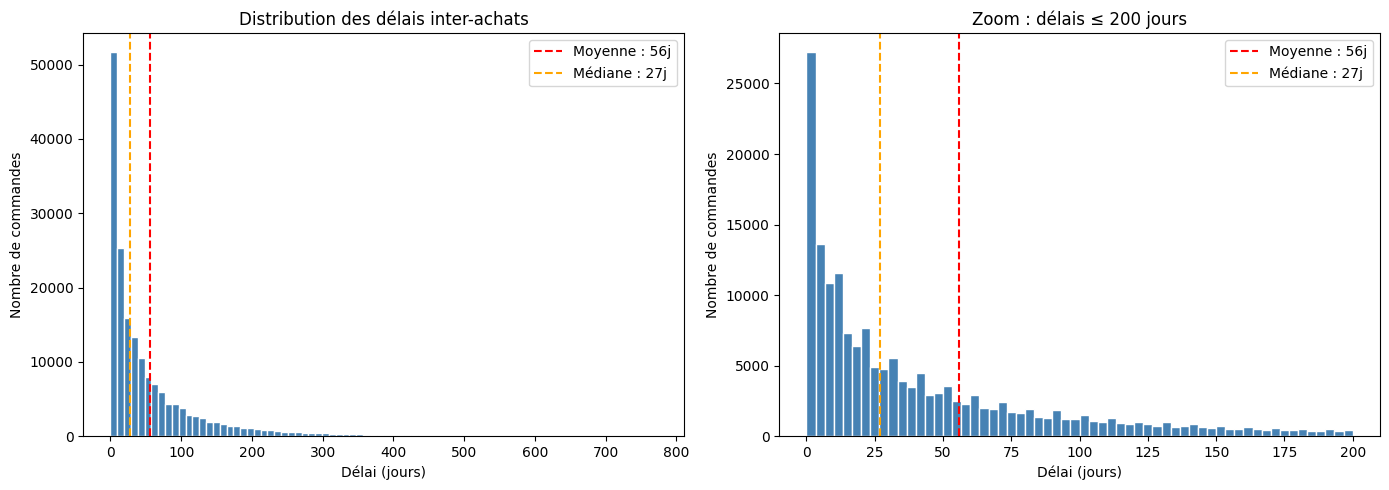

% de délais > 90j  : 19.8%
% de délais > 180j : 7.3%
% de délais > 365j : 1.1%


In [9]:

# Distribution des délais inter-achats (en jours)
delays_days = df_final_delays.dt.days

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(delays_days, bins=80, color='steelblue', edgecolor='white')
axes[0].axvline(delai_moyen.days, color='red', linestyle='--', label=f'Moyenne : {delai_moyen.days}j')
axes[0].axvline(delai_median.days, color='orange', linestyle='--', label=f'Médiane : {delai_median.days}j')
axes[0].set_title('Distribution des délais inter-achats')
axes[0].set_xlabel('Délai (jours)')
axes[0].set_ylabel('Nombre de commandes')
axes[0].legend()

# Zoom sur les 200 premiers jours pour voir la masse principale
axes[1].hist(delays_days[delays_days <= 200], bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(delai_moyen.days, color='red', linestyle='--', label=f'Moyenne : {delai_moyen.days}j')
axes[1].axvline(delai_median.days, color='orange', linestyle='--', label=f'Médiane : {delai_median.days}j')
axes[1].set_title('Zoom : délais ≤ 200 jours')
axes[1].set_xlabel('Délai (jours)')
axes[1].set_ylabel('Nombre de commandes')
axes[1].legend()

plt.tight_layout()
plt.show()

# La queue droite est bien visible : certains clients ont des délais > 300j (très saisonniers)
print(f"% de délais > 90j  : {(delays_days > 90).mean()*100:.1f}%")
print(f"% de délais > 180j : {(delays_days > 180).mean()*100:.1f}%")
print(f"% de délais > 365j : {(delays_days > 365).mean()*100:.1f}%")


In [10]:

# Percentiles pour choisir un seuil de churn objectif
print("Percentiles des délais inter-achats :")
for p in [50, 75, 90, 95, 99]:
    print(f"  P{p} : {int(np.percentile(delays_days, p))} jours")

# Choix du seuil : on retient le P90
# - La médiane (~27j) et la moyenne (~56j) montrent une forte asymétrie
# - Le P75 correspond encore à la fréquence normale des clients réguliers
# - Au-delà du P90, on entre clairement dans la queue droite :
#   clients occasionnels ou très saisonniers
# - Un client sans achat depuis 90j a très probablement rompu son cycle habituel
SEUIL_CHURN = int(np.percentile(delays_days, 90))
print(f"\nSeuil de churn retenu : {SEUIL_CHURN} jours (P90)")


Percentiles des délais inter-achats :
  P50 : 27 jours
  P75 : 72 jours
  P90 : 151 jours
  P95 : 218 jours
  P99 : 371 jours

Seuil de churn retenu : 151 jours (P90)


In [11]:

# Labellisation des clients : churné ou non
# Date de référence = dernière date observée dans le dataset
date_ref = df_transaction['invoice_date'].max()

# Recency : nombre de jours depuis la dernière commande de chaque client
last_order = df_transaction.groupby('customer_id')['invoice_date'].max()
recency = (date_ref - last_order).dt.days

# churn = 1 si inactif depuis plus du seuil, 0 sinon
churn = (recency > SEUIL_CHURN).astype(int)

df_churn = pd.DataFrame({'recency_days': recency, 'churn': churn})

print(f"Date de référence : {date_ref.date()}")
print(f"Seuil de churn    : {SEUIL_CHURN} jours\n")
print(f"Clients churné  (churn=1) : {churn.sum()} ({churn.mean()*100:.1f}%)")
print(f"Clients actifs  (churn=0) : {(churn == 0).sum()} ({(churn == 0).mean()*100:.1f}%)")
print()
print(df_churn.head(10))


Date de référence : 2011-12-09
Seuil de churn    : 151 jours

Clients churné  (churn=1) : 31190 (63.5%)
Clients actifs  (churn=0) : 17956 (36.5%)

             recency_days  churn
customer_id                     
12346.0               325      1
12347.0                 1      0
12348.0                74      0
12349.0                18      0
12350.0               309      1
12351.0               374      1
12352.0                35      0
12353.0               203      1
12354.0               231      1
12355.0               213      1


# Étape 2: Feature Engineering orienté désengagement

Construire des features qui capturent les signaux de désengagement :
- **Tendance de la fréquence** : le client commande-t-il de moins en moins souvent ?
- **Tendance du montant** : le panier moyen diminue-t-il ?
- **Récence relative** : récence actuelle comparée à la récence moyenne historique du client
- **Nombre de mois sans achat** sur les 6 derniers mois
- **Ratio dernière commande / panier moyen historique**
- **Features RFM et comportementales**

In [12]:
# Préparation des données pour le feature engineering
df_transaction['invoice_date'] = pd.to_datetime(df_transaction['invoice_date'])

# Date de référence = dernière date observée dans le dataset
date_ref = df_transaction['invoice_date'].max()
print(f"Date de référence : {date_ref.date()}")

# Filtrer les clients avec customer_id valide
df_valid = df_transaction[df_transaction['customer_id'].notna()].copy()
print(f"Transactions avec customer_id valide : {len(df_valid):,}")
print(f"Clients uniques : {df_valid['customer_id'].nunique():,}")

Date de référence : 2011-12-09
Transactions avec customer_id valide : 1,392,225
Clients uniques : 49,146


In [13]:
# =============================================================================
# 2.1 TENDANCE DE LA FRÉQUENCE : le client commande-t-il de moins en moins souvent ?
# =============================================================================

# On calcule le délai inter-achat moyen sur la 1ère moitié vs 2ème moitié des commandes du client
# Une augmentation du délai moyen indique un désengagement

def calc_frequency_trend(group):
    """
    Compare la fréquence d'achat entre la 1ère et 2ème moitié de l'historique du client.
    Retourne la différence (delay_recent - delay_early) / delay_early
    Si positif = client ralentit ses achats (signal de désengagement)
    """
    if len(group) < 4:  # Besoin d'au moins 4 commandes pour calculer une tendance
        return np.nan
    
    dates = group['invoice_date'].sort_values()
    delays = dates.diff().dt.days.dropna()
    
    if len(delays) < 2:
        return np.nan
    
    mid = len(delays) // 2
    early_avg = delays.iloc[:mid].mean()
    recent_avg = delays.iloc[mid:].mean()
    
    if early_avg == 0:
        return np.nan
    
    return (recent_avg - early_avg) / early_avg  # % de changement

# Agréger par customer_id et invoice_date pour avoir les commandes uniques
df_orders = df_valid.groupby(['customer_id', 'invoice_id', 'invoice_date']).agg({
    'total_price': 'sum'
}).reset_index()

# Calcul de la tendance de fréquence pour chaque client
freq_trend = df_orders.groupby('customer_id').apply(calc_frequency_trend, include_groups=False)
freq_trend.name = 'frequency_trend'

print("Tendance de fréquence (positif = ralentissement) :")
print(freq_trend.describe())
print(f"\nClients avec tendance calculable : {freq_trend.notna().sum()}")

Tendance de fréquence (positif = ralentissement) :
count    16699.000000
mean         1.467007
std         10.159974
min         -1.000000
25%         -0.387192
50%          0.066212
75%          0.899704
max        471.000000
Name: frequency_trend, dtype: float64

Clients avec tendance calculable : 16699


In [14]:
# =============================================================================
# 2.2 TENDANCE DU MONTANT : le panier moyen diminue-t-il ?
# =============================================================================

def calc_amount_trend(group):
    """
    Compare le panier moyen entre la 1ère et 2ème moitié de l'historique du client.
    Retourne la différence (amount_recent - amount_early) / amount_early
    Si négatif = panier moyen diminue (signal de désengagement)
    """
    if len(group) < 4:  # Besoin d'au moins 4 commandes pour calculer une tendance
        return np.nan
    
    amounts = group.sort_values('invoice_date')['total_price'].values
    
    mid = len(amounts) // 2
    early_avg = amounts[:mid].mean()
    recent_avg = amounts[mid:].mean()
    
    if early_avg == 0:
        return np.nan
    
    return (recent_avg - early_avg) / early_avg  # % de changement

# Calcul de la tendance du montant pour chaque client
amount_trend = df_orders.groupby('customer_id').apply(calc_amount_trend, include_groups=False)
amount_trend.name = 'amount_trend'

print("Tendance du montant (négatif = diminution du panier) :")
print(amount_trend.describe())
print(f"\nClients avec tendance calculable : {amount_trend.notna().sum()}")

Tendance du montant (négatif = diminution du panier) :
count    1.677200e+04
mean    -7.458883e+11
std      1.281606e+14
min     -1.618540e+16
25%     -3.983675e-01
50%     -5.856691e-03
75%      6.454915e-01
max      3.675360e+15
Name: amount_trend, dtype: float64

Clients avec tendance calculable : 16772


In [22]:
# récence actuelle vs récence moyenne historique

# Calcul du délai moyen historique de chaque client
def calc_avg_delay(group):
    """Calcule le délai moyen entre commandes pour un client"""
    if len(group) < 2:
        return np.nan
    dates = group['invoice_date'].sort_values()
    delays = dates.diff().dt.days.dropna()
    if len(delays) == 0:
        return np.nan
    return delays.mean()

avg_delay_per_customer = df_orders.groupby('customer_id').apply(calc_avg_delay, include_groups=False)
avg_delay_per_customer.name = 'avg_historical_delay'

# Récence actuelle (jours depuis dernière commande)
last_purchase = df_orders.groupby('customer_id')['invoice_date'].max()
recency_days = (date_ref - last_purchase).dt.days
recency_days.name = 'recency_days'

# Récence relative = récence actuelle / délai moyen historique
# Si > 1, le client est plus en retard que d'habitude (signal de désengagement)
recency_relative = recency_days / avg_delay_per_customer
recency_relative.name = 'recency_relative'

print("Récence relative (>1 = plus en retard que d'habitude) :")
print(recency_relative.describe())
print(f"\nClients avec récence relative calculable : {recency_relative.notna().sum()}")

Récence relative (>1 = plus en retard que d'habitude) :
count    2.881900e+04
mean              inf
std               NaN
min      0.000000e+00
25%      8.683191e-01
50%      1.914634e+00
75%      3.975719e+00
max               inf
Name: recency_relative, dtype: float64

Clients avec récence relative calculable : 28819


/home/browngreg/dia3/data_marketing/data_marketing_DIA3/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [23]:
# NOMBRE DE MOIS SANS ACHAT SUR LES 6 DERNIERS MOIS

six_months_ago = date_ref - pd.DateOffset(months=6)

# Pour chaque client, compter les mois avec au moins un achat dans les 6 derniers mois
df_recent = df_orders[df_orders['invoice_date'] >= six_months_ago].copy()
df_recent['month'] = df_recent['invoice_date'].dt.to_period('M')

# Mois uniques avec achat par client
months_with_purchase = df_recent.groupby('customer_id')['month'].nunique()
months_with_purchase.name = 'months_with_purchase_last6m'

# Nombre de mois sans achat = 6 - mois avec achat
# Pour les clients sans achat du tout dans cette période, on met 6
all_customers = df_orders['customer_id'].unique()
months_without_purchase = pd.Series(index=all_customers, data=6, name='months_without_purchase_last6m')
months_without_purchase.loc[months_with_purchase.index] = 6 - months_with_purchase

print("Nombre de mois sans achat sur les 6 derniers mois :")
print(months_without_purchase.value_counts().sort_index())
print(f"\nMoyenne : {months_without_purchase.mean():.1f} mois")

Nombre de mois sans achat sur les 6 derniers mois :
months_without_purchase_last6m
-1      157
 0      305
 1      540
 2     1081
 3     2253
 4     4629
 5    10998
 6    29183
Name: count, dtype: int64

Moyenne : 5.2 mois


In [24]:
# RATIO DERNIÈRE COMMANDE / PANIER MOYEN HISTORIQUE

# Panier moyen historique par client
avg_basket = df_orders.groupby('customer_id')['total_price'].mean()
avg_basket.name = 'avg_basket_historical'

# Montant de la dernière commande
last_order_date = df_orders.groupby('customer_id')['invoice_date'].transform('max')
df_last_orders = df_orders[df_orders['invoice_date'] == last_order_date]
last_order_amount = df_last_orders.groupby('customer_id')['total_price'].first()
last_order_amount.name = 'last_order_amount'

# Ratio = dernière commande / moyenne historique
# Si < 1, la dernière commande est plus faible que d'habitude (signal de désengagement)
last_order_ratio = last_order_amount / avg_basket
last_order_ratio.name = 'last_order_ratio'

print("Ratio dernière commande / panier moyen historique :")
print(f"  < 0.5 (commande très faible) : {(last_order_ratio < 0.5).sum()} clients ({(last_order_ratio < 0.5).mean()*100:.1f}%)")
print(f"  0.5-1 (légèrement en baisse) : {((last_order_ratio >= 0.5) & (last_order_ratio < 1)).sum()} clients")
print(f"  >= 1 (stable ou en hausse)   : {(last_order_ratio >= 1).sum()} clients")
print(f"\nMoyenne : {last_order_ratio.mean():.2f}")
print(f"Médiane : {last_order_ratio.median():.2f}")

Ratio dernière commande / panier moyen historique :
  < 0.5 (commande très faible) : 8036 clients (16.4%)
  0.5-1 (légèrement en baisse) : 8558 clients
  >= 1 (stable ou en hausse)   : 32334 clients

Moyenne : nan
Médiane : 1.00


/home/browngreg/dia3/data_marketing/data_marketing_DIA3/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


In [25]:
# FEATURES RFM ET COMPORTEMENTALES

# --- RFM Features ---
# Recency : déjà calculé (recency_days)
# Frequency : nombre de commandes
frequency = df_orders.groupby('customer_id')['invoice_id'].nunique()
frequency.name = 'frequency'

# Monetary : montant total dépensé
monetary = df_orders.groupby('customer_id')['total_price'].sum()
monetary.name = 'monetary'

# --- Features comportementales additionnelles ---
# Nombre de jours entre la 1ère et dernière commande (tenure)
first_purchase = df_orders.groupby('customer_id')['invoice_date'].min()
tenure_days = (last_purchase - first_purchase).dt.days
tenure_days.name = 'tenure_days'

# Nombre moyen d'articles par commande
items_per_order = df_valid.groupby(['customer_id', 'invoice_id']).size().groupby('customer_id').mean()
items_per_order.name = 'avg_items_per_order'

# Nombre de produits uniques achetés
unique_products = df_valid.groupby('customer_id')['product_code'].nunique()
unique_products.name = 'unique_products'

# Valeur moyenne par commande
avg_order_value = monetary / frequency
avg_order_value.name = 'avg_order_value'

# Taux de retour
returns = df_valid[df_valid['retour_commande'] == 'oui'].groupby('customer_id').size()
total_orders_per_customer = df_valid.groupby('customer_id')['invoice_id'].nunique()
return_rate = (returns / total_orders_per_customer).fillna(0)
return_rate.name = 'return_rate'

print("Features RFM et comportementales calculées :")
print(f"  - Recency (jours depuis dernier achat)")
print(f"  - Frequency (nombre de commandes)")
print(f"  - Monetary (montant total)")
print(f"  - Tenure (jours entre 1ère et dernière commande)")
print(f"  - Avg items per order")
print(f"  - Unique products purchased")
print(f"  - Avg order value")
print(f"  - Return rate")

Features RFM et comportementales calculées :
  - Recency (jours depuis dernier achat)
  - Frequency (nombre de commandes)
  - Monetary (montant total)
  - Tenure (jours entre 1ère et dernière commande)
  - Avg items per order
  - Unique products purchased
  - Avg order value
  - Return rate


In [26]:
# ASSEMBLAGE DU DATASET FINAL AVEC TOUTES LES FEATURES

# Créer le DataFrame de features
df_features = pd.DataFrame(index=all_customers)
df_features.index.name = 'customer_id'

# Features de désengagement (tendance)
df_features['frequency_trend'] = freq_trend
df_features['amount_trend'] = amount_trend
df_features['recency_relative'] = recency_relative
df_features['months_without_purchase_last6m'] = months_without_purchase
df_features['last_order_ratio'] = last_order_ratio

# Features RFM
df_features['recency_days'] = recency_days
df_features['frequency'] = frequency
df_features['monetary'] = monetary

# Features comportementales
df_features['tenure_days'] = tenure_days
df_features['avg_items_per_order'] = items_per_order
df_features['unique_products'] = unique_products
df_features['avg_order_value'] = avg_order_value
df_features['return_rate'] = return_rate

# Joindre le label churn (créé à l'étape 1)
df_features['churn'] = df_churn['churn']

print(f"Dataset final : {len(df_features)} clients, {len(df_features.columns)} features")
print("\n--- Aperçu des features ---")
df_features.info()
print("\n--- Statistiques descriptives ---")
df_features.describe().T

Dataset final : 49146 clients, 14 features

--- Aperçu des features ---
<class 'pandas.DataFrame'>
Index: 49146 entries, 12346.0 to 63441.0
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   frequency_trend                 16699 non-null  float64
 1   amount_trend                    16772 non-null  float64
 2   recency_relative                28819 non-null  float64
 3   months_without_purchase_last6m  49146 non-null  int64  
 4   last_order_ratio                48928 non-null  float64
 5   recency_days                    49146 non-null  int64  
 6   frequency                       49146 non-null  int64  
 7   monetary                        49146 non-null  float64
 8   tenure_days                     49146 non-null  int64  
 9   avg_items_per_order             49146 non-null  float64
 10  unique_products                 49146 non-null  int64  
 11  avg_order_value              

/home/browngreg/dia3/data_marketing/data_marketing_DIA3/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/browngreg/dia3/data_marketing/data_marketing_DIA3/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,count,mean,std,min,25%,50%,75%,max
frequency_trend,16699.0,1.467007e+00,1.015997e+01,-1.000000e+00,-0.387192,0.066212,0.899704,4.710000e+02
amount_trend,16772.0,-7.458883e+11,1.281606e+14,-1.618540e+16,-0.398367,-0.005857,0.645491,3.675360e+15
recency_relative,28819.0,inf,NaN,0.000000e+00,0.868319,1.914634,3.975719,inf
months_without_purchase_last6m,49146.0,5.247792e+00,1.205782e+00,-1.000000e+00,5.000000,6.000000,6.000000,6.000000e+00
last_order_ratio,48928.0,NaN,NaN,-inf,0.747876,1.000000,1.000000,inf
recency_days,49146.0,3.592634e+02,3.173113e+02,0.000000e+00,87.000000,269.000000,567.000000,1.617000e+03
frequency,49146.0,4.646889e+00,1.015272e+01,1.000000e+00,1.000000,2.000000,5.000000,5.100000e+02
monetary,49146.0,6.073808e+02,4.904539e+03,-2.511109e+04,28.200000,84.650000,327.495000,5.703806e+05
tenure_days,49146.0,2.058266e+02,2.393727e+02,0.000000e+00,0.000000,84.000000,403.000000,8.390000e+02
avg_items_per_order,49146.0,4.893473e+00,8.097527e+00,1.000000e+00,1.666667,2.750000,4.400000,2.360000e+02


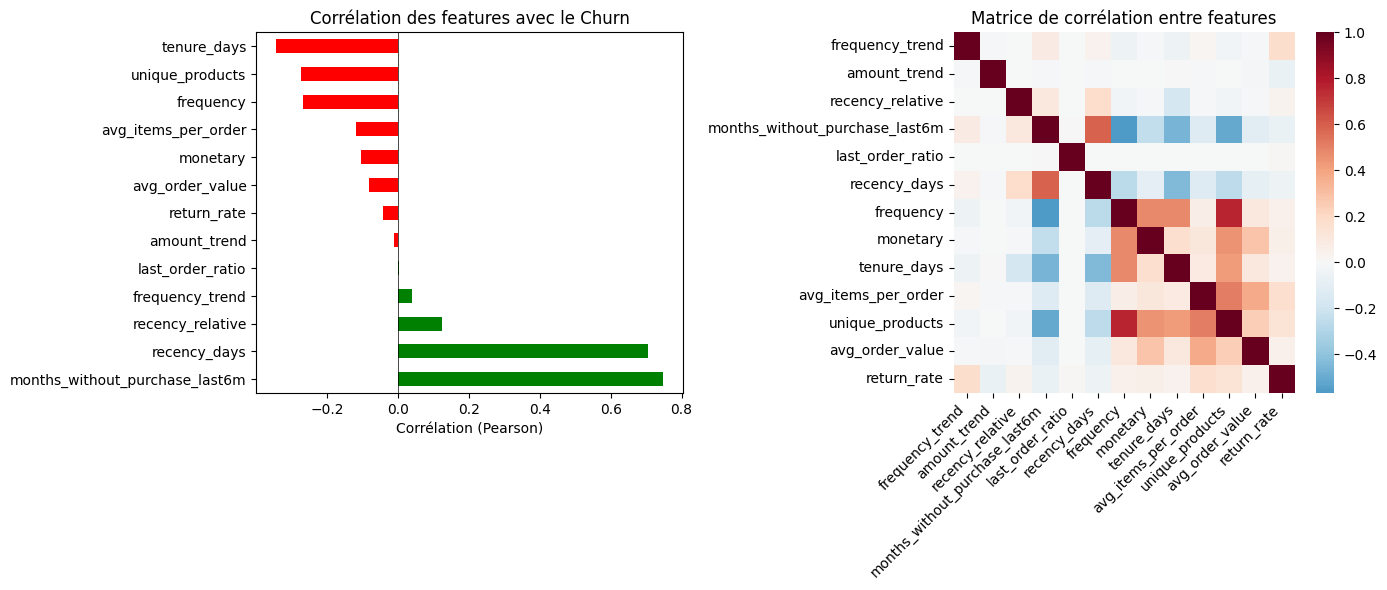


Top 5 features les plus corrélées avec le churn :
months_without_purchase_last6m    0.748289
recency_days                      0.704292
recency_relative                  0.123729
frequency_trend                   0.040280
last_order_ratio                  0.003436
Name: churn, dtype: float64


In [27]:
# ANALYSE DES CORRÉLATIONS AVEC LE CHURN 
import seaborn as sns

# Corrélation de chaque feature avec le churn
correlations = df_features.corr()['churn'].drop('churn').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barplot des corrélations
colors = ['green' if c > 0 else 'red' for c in correlations]
correlations.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Corrélation des features avec le Churn')
axes[0].set_xlabel('Corrélation (Pearson)')
axes[0].axvline(0, color='black', linestyle='-', linewidth=0.5)

# Heatmap des corrélations entre features
sns.heatmap(df_features.drop('churn', axis=1).corr(), 
            cmap='RdBu_r', center=0, ax=axes[1],
            xticklabels=True, yticklabels=True,
            annot=False, fmt='.2f')
axes[1].set_title('Matrice de corrélation entre features')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\nTop 5 features les plus corrélées avec le churn :")
print(correlations.head())

In [28]:
# GESTION DES VALEURS MANQUANTES ET PRÉPARATION POUR LA MODÉLISATION

# Analyser les valeurs manquantes
missing = df_features.isnull().sum()
missing_pct = (missing / len(df_features) * 100).round(1)
missing_info = pd.DataFrame({'Manquantes': missing, '%': missing_pct})
print("Valeurs manquantes par feature :")
print(missing_info[missing_info['Manquantes'] > 0])

# Stratégie de remplacement :
# - frequency_trend, amount_trend : 0 (pas de tendance = neutre)
# - recency_relative : remplacer par la médiane (clients avec 1 seul achat)
# - last_order_ratio : 1 (neutre)

df_features_clean = df_features.copy()

# Remplacer les NaN des features de tendance par 0 (neutre = pas de changement)
df_features_clean['frequency_trend'] = df_features_clean['frequency_trend'].fillna(0)
df_features_clean['amount_trend'] = df_features_clean['amount_trend'].fillna(0)

# Remplacer recency_relative NaN par la médiane
df_features_clean['recency_relative'] = df_features_clean['recency_relative'].fillna(
    df_features_clean['recency_relative'].median()
)

# Pour les autres NaN potentiels, utiliser la médiane
for col in df_features_clean.columns:
    if df_features_clean[col].isnull().any():
        df_features_clean[col] = df_features_clean[col].fillna(df_features_clean[col].median())

print(f"\nDataset nettoyé : {len(df_features_clean)} clients")
print(f"Valeurs manquantes restantes : {df_features_clean.isnull().sum().sum()}")
print(f"\nDataset prêt pour la modélisation (Étape 3)")

# Aperçu final
df_features_clean.head(10)

Valeurs manquantes par feature :
                  Manquantes     %
frequency_trend        32447  66.0
amount_trend           32374  65.9
recency_relative       20327  41.4
last_order_ratio         218   0.4

Dataset nettoyé : 49146 clients
Valeurs manquantes restantes : 0

Dataset prêt pour la modélisation (Étape 3)


,frequency_trend,amount_trend,recency_relative,months_without_purchase_last6m,last_order_ratio,recency_days,frequency,monetary,tenure_days,avg_items_per_order,unique_products,avg_order_value,return_rate,churn
customer_id,,,,,,,,,,,,,,
12346.0,8.916667,-2.142983,13.231552,6,25359.899497,325,17,-51.74,400,2.764706,30,-3.043529,0.764706,1
12347.0,0.168269,0.021195,0.017544,2,0.365447,1,8,4921.53,402,27.750000,126,615.191250,0.000000,0
12348.0,1.042017,-0.459209,0.817680,5,0.767555,74,5,2019.40,362,10.200000,25,403.880000,0.000000,0
12349.0,2.359756,1.144942,0.100699,5,1.995157,18,5,4404.54,716,36.000000,139,880.908000,1.000000,0
12350.0,0.000000,0.000000,1.914634,6,1.000000,309,1,334.40,0,17.000000,17,334.400000,0.000000,1
12351.0,0.000000,0.000000,1.914634,6,1.000000,374,1,300.93,0,21.000000,21,300.930000,0.000000,1
12352.0,1.268519,-30.955487,1.189802,4,2.145071,35,13,1889.21,356,8.692308,70,145.323846,0.769231,0
12353.0,0.000000,0.000000,0.995098,6,0.437604,203,2,406.76,204,12.000000,23,203.380000,0.000000,1
12354.0,0.000000,0.000000,1.914634,6,1.000000,231,1,1079.40,0,58.000000,58,1079.400000,0.000000,1
